### Build A Basic Chatbot With Langgraph(GRAPH API)

In [36]:
from typing_extensions import Annotated , TypedDict
from langgraph.graph import StateGraph , START ,END
from langgraph.graph.message import add_messages ### reducers

In [37]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages : Annotated[list , add_messages]


In [38]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')


In [49]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model='openai/gpt-oss-20b'
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021E1E3F11D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021E1E3F1BD0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
## Node Functionality
def chatbot(state : State):
    return {"messages" : [llm.invoke(state['messages'])]}

In [ ]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot" , chatbot)

## Adding Edges
graph_builder.add_edge(START , "llmchatbot")
graph_builder.add_edge("llmchatbot" , END)

## compile the graph
graph = graph_builder.compile()


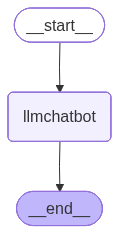

In [12]:
## Visualize the graph
from IPython.display import  display , Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
response =  graph.invoke({'messages' : "Hi"})

In [19]:
response['messages'][-1].content

'Hello! 👋 How can I assist you today?'

In [23]:
for event in graph.stream({'messages' : "hi How are you!"}):
    for value in event.values():
        print(value['messages'][-1].content)

Hi there! I’m doing great—thanks for asking. How about you?


### ChatBot with tools

In [25]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

In [26]:
tool.invoke("What happened at the last wimbledon")

{'query': 'What happened at the last wimbledon',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Wimbledon_Championships',
   'title': 'Wimbledon Championships',
   'content': '# Wimbledon Championships. The **Wimbledon Championships**, commonly called **Wimbledon**, is a tennis tournament organised annually by the All England Lawn Tennis and Croquet Club in collaboration with the Lawn Tennis Association in Wimbledon, London. It is chronologically the third of the four Grand Slam "Grand Slam (tennis)") tennis events each year, held after the Australian Open and the French Open and before the US Open "US Open (tennis)"). It is the oldest tennis tournament in the world and is widely regarded as the most prestigious. Wimbledon has been held since 1877 and is played on outdoor grass courts; it is the only tennis major still played on grass, the traditional surface. The tournament traditionally takes place over two weeks in l

In [ ]:
def multiply(a:int , b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): seccond int

    Returns:
        int: output int
    """
    return a*b

In [ ]:
tools = [tool , multiply]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021E1E3F11D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021E1E3F1BD0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': '

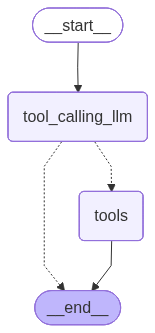

In [54]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition

## Node definition
def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tools.invoke(state['messages'])]}

#Graph
builder = StateGraph(State)

## Add Nodes
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node('tools' , ToolNode(tools) )

## Add Edges
builder.add_edge(START , 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools' ,END )

## compile the graph
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [58]:
response = graph.invoke({"messages" :" What is recent ai news"})

In [59]:
response

{'messages': [HumanMessage(content=' What is recent ai news', additional_kwargs={}, response_metadata={}, id='93e49289-3613-4fe1-8016-fe5235d159ac'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer "What is recent ai news". We should browse for recent AI news. Use search.', 'tool_calls': [{'id': 'fc_ce722d0e-1f0f-43ff-9c9c-59ee7d73f1b5', 'function': {'arguments': '{"query":"recent AI news 2026 July 2026","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 352, 'total_tokens': 418, 'completion_time': 0.071962593, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.017412798, 'prompt_tokens_details': None, 'queue_time': 0.280539269, 'total_time': 0.089375391}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_

In [60]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

 What is recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ce722d0e-1f0f-43ff-9c9c-59ee7d73f1b5)
 Call ID: fc_ce722d0e-1f0f-43ff-9c9c-59ee7d73f1b5
  Args:
    query: recent AI news 2026 July 2026
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 July 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://markets.businessinsider.com/news/stocks/as-ai-moves-into-the-physical-world-humanity-agi-summit-2026-brings-global-leaders-to-stanford-1036305352", "title": "As AI Moves Into the Physical World, Humanity & AGI Summit 2026 Brings Global Leaders to Stanford - markets.businessinsider.com", "score": 0.86632514, "published_date": "Wed, 08 Jul 2026 00:41:57 GMT", "content

In [69]:
response = graph.invoke({"messages" : "What is 3 multipied by 4 and then multipied by 5"})

In [70]:
response

{'messages': [HumanMessage(content='What is 3 multipied by 4 and then multipied by 5', additional_kwargs={}, response_metadata={}, id='67966ee6-220d-4160-aca4-1ceec317b948'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to compute 3 * 4 * 5. That\'s 12 * 5 = 60. They also want to use the mutiply function? The tool is named "mutiply" (typo). The user asked: "What is 3 multipied by 4 and then multipied by 5". We can compute. The user may want the result. Provide answer. We can use the function to multiply 3 and 4, then multiply result with 5. But the function only multiplies two numbers. We can chain. Let\'s call function twice. Use the function to compute 3*4 = 12. Then 12*5 = 60. We\'ll call the function.', 'tool_calls': [{'id': 'fc_2fb95a43-5df0-4596-b002-24418f7ad32b', 'function': {'arguments': '{"a":3,"b":4}', 'name': 'mutiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 177, 'prompt_tokens': 363, 'total_tokens': 540, 

In [71]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 3 multipied by 4 and then multipied by 5
================================== Ai Message ==================================
Tool Calls:
  mutiply (fc_2fb95a43-5df0-4596-b002-24418f7ad32b)
 Call ID: fc_2fb95a43-5df0-4596-b002-24418f7ad32b
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: mutiply

12


### ReAct Agent Architecture

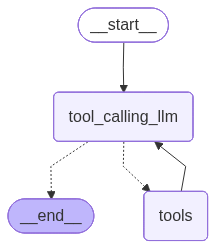

In [72]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition

## Node definition
def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tools.invoke(state['messages'])]}

#Graph
builder = StateGraph(State)

## Add Nodes
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node('tools' , ToolNode(tools) )

## Add Edges
builder.add_edge(START , 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools' ,"tool_calling_llm" )

## compile the graph
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [73]:
response = graph.invoke({"messages" : "What is 3 multipied by 4 and then multipied by 5"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 3 multipied by 4 and then multipied by 5
================================== Ai Message ==================================

3 × 4 = 12, and then 12 × 5 = **60**.


In [74]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_999ded4e-6d98-4b47-b008-00f3e8152e34)
 Call ID: fc_999ded4e-6d98-4b47-b008-00f3e8152e34
  Args:
    query: recent AI news
    search_depth: basic
    time_range: month
================================= Tool Message =================================
Name: tavily_search

No search results found for 'recent AI news'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7c831442-0f2e-4fb4-a4e5-454f60578ac4)
 Call ID: fc_7c831442-0f2e-4fb4-a4e5-454f60578ac4
  Args:
    query: latest AI news 2026
    search_depth: basic
    ti

### Adding Memory In Agentic Graph

In [76]:
response=graph.invoke({"messages":"Hello my name is Ankit"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ankit
================================== Ai Message ==================================

Hello Ankit! How can I help you today?


In [77]:
response=graph.invoke({"messages":"what is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I’m not sure—could you let me know your name?


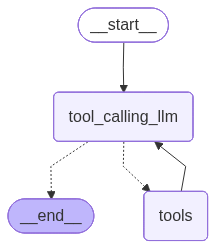

In [89]:
## Stategraph
from langgraph.graph import StateGraph , START , END
from langgraph.prebuilt import ToolNode , tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node definition
def tool_calling_llm(state : State):
    return {"messages" : [llm_with_tools.invoke(state['messages'])]}

#Graph
builder = StateGraph(State)

## Add Nodes
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node('tools' , ToolNode(tools) )

## Add Edges
builder.add_edge(START , 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools' ,"tool_calling_llm" )

## compile the graph
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [90]:
config={"configurable": {"thread_id": "1"}}
response=graph.invoke({"messages":"Hello my name is Ankit"} , config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ankit
================================== Ai Message ==================================

Hello Ankit! How can I help you today?


In [91]:
response=graph.invoke({"messages":"hey What is my name"} , config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ankit
================================== Ai Message ==================================

Hello Ankit! How can I help you today?
================================ Human Message =================================

hey What is my name
================================== Ai Message ==================================

Your name is Ankit.


In [93]:
response=graph.invoke({"messages":"Do you remember my name"} , config=config)
response['messages'][-1].content

'Yes, I remember—your name is Ankit.'

### Streaming

In [95]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [98]:
def superbot(state:State):
    return {"messages" : [llm.invoke(state['messages'])]}

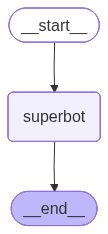

In [101]:
graph = StateGraph(State)

graph.add_node('superbot' , superbot)
graph.add_edge(START , 'superbot')
graph.add_edge('superbot' , END)


graph_builder = graph.compile(checkpointer=memory)

from IPython.display import display , Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [102]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='8efbe8da-c526-4ced-ae4d-6cd0f8dec1cf'),
  AIMessage(content='Hey Krish! 👋 Great to meet you. Cricket’s an awesome sport—do you follow any particular team or player? What’s your favorite part of the game?', additional_kwargs={'reasoning_content': "We need to respond. It's a casual greeting. We can reply friendly, ask about cricket."}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 82, 'total_tokens': 146, 'completion_time': 0.099908726, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.004883232, 'prompt_tokens_details': None, 'queue_time': 0.321472184, 'total_time': 0.104791958}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d81-cdd2-7953-bb2d-e1a81bd6bfa3-0', tool_call

# Streaming

Methods: `.stream()` and `astream()`

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state:

- **values**: This streams the full state of the graph after each node is called.
- **updates**: This streams updates to the state of the graph after each node is called.

In [103]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Ankit And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hey Ankit! 👋 Great to meet another cricket fan. Which team or player do you follow most? Or maybe you’re into a particular format—Test, ODI, T20, or even the IPL? Let me know, and we can chat about recent matches, stats, or even some fun trivia!', additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi, My name is Ankit And I like cricket". We can greet them, maybe ask about cricket. There\'s no explicit instruction. Just a friendly conversation. We should respond politely, ask about cricket interest.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.129612008, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.004578036, 'prompt_tokens_details': None, 'queue_time': 0.31523262, 'total_time': 0.134190044}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1074f9ce08', 'service_tier': 'on_demand', 'finish_reaso

In [104]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Ankit And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Ankit And I like cricket', additional_kwargs={}, response_metadata={}, id='4cfecc06-71a9-41d8-bae2-0d126b4cbee5'), AIMessage(content='Hey Ankit! 👋 Great to meet another cricket fan. Which team or player do you follow most? Or maybe you’re into a particular format—Test, ODI, T20, or even the IPL? Let me know, and we can chat about recent matches, stats, or even some fun trivia!', additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi, My name is Ankit And I like cricket". We can greet them, maybe ask about cricket. There\'s no explicit instruction. Just a friendly conversation. We should respond politely, ask about cricket interest.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.129612008, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.004578036, 'prompt_tokens_details': None, 'queue_time': 0.31523262, 'total_

In [105]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Ankit And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hello Ankit! 👋  \nIt’s great to meet a fellow cricket fan. What’s your favorite part of the game? Are you more into batting, bowling, or the strategy behind it? Do you have a favorite team or player you follow? Let me know – I’d love to chat more about cricket with you!', additional_kwargs={'reasoning_content': 'We need to respond to user: "Hi, My name is Ankit And I like cricket". We should greet, ask about cricket interest, maybe ask what aspect they like: batting, bowling, teams, matches. Also maintain friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.141881447, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.004905227, 'prompt_tokens_details': None, 'queue_time': 0.31507421, 'total_time': 0.146786674}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_228717f27c', 'service_tier': 'on_demand', 'finish_reason': '

In [106]:

for chunk in graph_builder.stream({'messages':"Hi,My name is Ankit And I like football. I am big fan of Argentina and Messi in FIFA"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Ankit And I like cricket', additional_kwargs={}, response_metadata={}, id='e7d208b5-cd1e-4342-bcc3-b9ddbe37f11c'), AIMessage(content='Hello Ankit! 👋  \nIt’s great to meet a fellow cricket fan. What’s your favorite part of the game? Are you more into batting, bowling, or the strategy behind it? Do you have a favorite team or player you follow? Let me know – I’d love to chat more about cricket with you!', additional_kwargs={'reasoning_content': 'We need to respond to user: "Hi, My name is Ankit And I like cricket". We should greet, ask about cricket interest, maybe ask what aspect they like: batting, bowling, teams, matches. Also maintain friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.141881447, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.004905227, 'prompt_tokens_details': None, 'queue_time': 0.31507421, 'total_time'

In [107]:

config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4d98-38e3-71e0-ba30-63f7e6a2d382', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='a2b6acb9-c91d-4d4b-9559-7a6d667ab725')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f4d98-3905-7973-9963-207d69662e18', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:512595b2-8928-ea91-ef0b-6ae53b08cdba'}, 'parent_ids': ['019f4d98-38e3-71e0-ba30-63f7e6a2d382']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':